# Model training using synthetic data - October 2025

## Fase 1: Importaciones y Métricas Personalizadas

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Librerías del modelo de Keras
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import SGD, Adam
from keras import callbacks
import tensorflow.keras.backend as K
from keras.models import load_model

# --- MÉTRICAS PERSONALIZADAS (de tu notebook original) ---
# Estas métricas son excelentes para evaluar el rendimiento
# en problemas de clasificación como el nuestro.

def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2 * ((precision * recall) / (precision + recall + K.epsilon()))

print("Fase 1 completada: Librerías importadas y métricas definidas.")

Fase 1 completada: Librerías importadas y métricas definidas.


## Fase 2: Carga y Preparación de Datos

In [3]:
# --- Carga de los nuevos datasets ---
# Asegúrate de que las rutas a tus archivos sean correctas
try:
    X = np.load('datasets/features_150k_17_11_25.csv.npy')
    y = np.load('datasets/labels_150k_17_11_25.csv.npy')
    print("Archivos CSV cargados exitosamente.")
except FileNotFoundError:
    print("Error: No se encontraron los archivos del dataset. Verifica las rutas.")
    # Detener la ejecución si no se encuentran los archivos
    assert False, "Deteniendo ejecución por falta de archivos."


# --- Separación en Train/Test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% para pruebas
    random_state=42 # Para reproducibilidad
)

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_test: {y_test.shape}")


# --- Normalización de Features (CORREGIDA)---
# Calculamos la media y std SOLO del set de entrenamiento
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

# >> INICIO DE LA CORRECCIÓN <<
# Se añade un valor muy pequeño (epsilon) a la desviación estándar 
# para evitar la división por cero en columnas con varianza nula.
epsilon = 1e-7
X_train = (X_train - mean) / (std + epsilon)
X_test = (X_test - mean) / (std + epsilon)

# Verificamos si hay algún valor NaN después de la normalización
if np.isnan(X_train).any():
    print("\\nAlerta: Se encontraron valores NaN en X_train después de la normalización.")
else:
    print("\\nNormalización segura completada. No se encontraron NaNs.")
# >> FIN DE LA CORRECCIÓN <<

# Convertir a arrays de numpy para Keras
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train).astype('float32')
y_test = np.array(y_test).astype('float32')

print("\\nFase 2 completada: Datos cargados, separados y normalizados correctamente.")

Archivos CSV cargados exitosamente.
Forma de X_train: (120000, 244)
Forma de y_train: (120000, 1649)
Forma de X_test: (30000, 244)
Forma de y_test: (30000, 1649)
\nNormalización segura completada. No se encontraron NaNs.
\nFase 2 completada: Datos cargados, separados y normalizados correctamente.


In [4]:
# --- Evaluación Final en el Set de Prueba ---
from keras.models import load_model

# Cargar el mejor modelo que acabamos de guardar
model = load_model(
    'sonar_model_multiobjeto.h5', 
    custom_objects={'f1_m': f1_m, 'precision_m': precision_m, 'recall_m': recall_m}
)
print("Modelo 'sonar_model_multiobjeto.h5' cargado.")

print("\nEvaluando el modelo final en el conjunto de prueba:")
score = model.evaluate(X_test, y_test, verbose=1)

print(f"\nResultados en el Test Set:")
print(f"  Pérdida (Loss): {score[0]:.4f}")
print(f"  F1-Score: {score[1]:.4f}")
print(f"  Precision: {score[2]:.4f}")
print(f"  Recall: {score[3]:.4f}")

# --- Ejemplo de Predicción ---
print("\nEjemplo de predicción en una muestra del test set:")
# Hacemos la predicción sobre todo el set de prueba
y_pred_probs = model.predict(X_test)

# Definimos un umbral para decidir si un cuadrante está "activo"
umbral_prediccion = 0.35
y_pred = (y_pred_probs > umbral_prediccion).astype(int)

for i in range(5):
    # Elegimos una muestra al azar para comparar
    indice_ejemplo = np.random.randint(0, len(y_test))
    
    cuadrantes_reales = np.where(y_test[indice_ejemplo] == 1)[0]
    cuadrantes_predichos = np.where(y_pred[indice_ejemplo] == 1)[0]
    
    print(f"\n--- Muestra #{indice_ejemplo} ---")
    print(f"Cuadrantes Reales:     {cuadrantes_reales}")
    print(f"Cuadrantes Predichos:  {cuadrantes_predichos}")

Modelo 'sonar_model_multiobjeto.h5' cargado.

Evaluando el modelo final en el conjunto de prueba:


2025-11-17 17:46:00.753348: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 197880000 exceeds 10% of free system memory.


938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - f1_m: 0.4608 - loss: 0.0039 - precision_m: 0.6566 - recall_m: 0.3576

Resultados en el Test Set:
  Pérdida (Loss): 0.0039
  F1-Score: 0.4608
  Precision: 0.6566
  Recall: 0.3576

Ejemplo de predicción en una muestra del test set:
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


2025-11-17 17:46:05.833712: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 197880000 exceeds 10% of free system memory.



--- Muestra #1504 ---
Cuadrantes Reales:     [460 461 462]
Cuadrantes Predichos:  [430 461 462]

--- Muestra #9713 ---
Cuadrantes Reales:     [ 938  999 1029]
Cuadrantes Predichos:  [937 999]

--- Muestra #6002 ---
Cuadrantes Reales:     [584]
Cuadrantes Predichos:  [584 585]

--- Muestra #16111 ---
Cuadrantes Reales:     [637]
Cuadrantes Predichos:  [575 637]

--- Muestra #8189 ---
Cuadrantes Reales:     [736 801 869 917]
Cuadrantes Predichos:  [735 785 801 869]


## Visualizacion de predicciones vs etiquetas reales

Dibujar punto en X=-91.0, Y=51.0
Dibujar punto en X=-55.0, Y=51.0
Dibujar punto en X=-49.0, Y=51.0
Dibujar punto en X=-55.0, Y=51.0
Dibujar punto en X=-49.0, Y=51.0


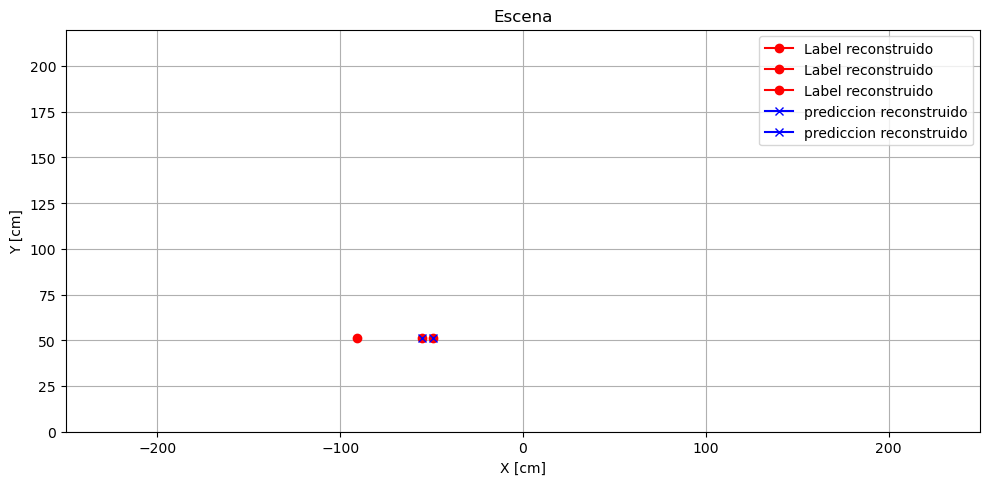

In [42]:
import seaborn as sns

# Cargamos el mapa de cuadarntes para reconstruir la posicion X, Y

mapa_centroides = np.load('mapa_de_cuadrantes.npy')
0
fig, (ax1) = plt.subplots(1, 1, figsize=(10, 8))

sample_number = 21
labels = y_test[sample_number]
predicciones = y_pred[sample_number]

for label in np.where(labels == 1)[0]:
    coordenadas = mapa_centroides[label]
    print(f"Dibujar punto en X={coordenadas[0]}, Y={coordenadas[1]}")
    ax1.plot(coordenadas[0],coordenadas[1] , color='red', marker='o', alpha=1, label='Label reconstruido')

for prediccion in np.where(predicciones == 1)[0]:
    coordenadas = mapa_centroides[prediccion]
    print(f"Dibujar punto en X={coordenadas[0]}, Y={coordenadas[1]}")
    ax1.plot(coordenadas[0],coordenadas[1] , color='blue', marker='x', alpha=1, label='prediccion reconstruido')


ax1.set_title(f"Escena")
ax1.set_xlabel("X [cm]"); ax1.set_ylabel("Y [cm]")
ax1.set_xlim(-250, 250); ax1.set_ylim(0, 220)
ax1.set_aspect('equal', adjustable='box'); ax1.grid(True); ax1.legend()

plt.tight_layout(); plt.show()

## Optimizacion del threshold y metricas de precion

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  # Barra de progreso para Jupyter
from scipy.spatial.distance import cdist
from keras.models import load_model
import tensorflow.keras.backend as K
from sklearn.model_selection import train_test_split
import pandas as pd # Para mostrar resultados bonitos

# =============================================================================
# 1. CONFIGURACIÓN Y CARGA (Igual que antes)
# =============================================================================

# Archivos (Asegúrate de que las rutas sean correctas)
MODEL_FILE = 'sonar_model_multiobjeto.h5'
X_FILE = 'datasets/features_150k_17_11_25.csv.npy'
Y_FILE = 'datasets/labels_150k_17_11_25.csv.npy'
MAP_FILE = 'mapa_de_cuadrantes.npy'
GRID_SIZE = 6.0 # cm (Tamaño de tu cuadrante original)

# Métricas Custom (Necesarias para cargar el modelo)
def recall_m(y_true, y_pred):
    return K.sum(K.round(K.clip(y_true * y_pred, 0, 1))) / (K.sum(K.round(K.clip(y_true, 0, 1))) + K.epsilon())
def precision_m(y_true, y_pred):
    return K.sum(K.round(K.clip(y_true * y_pred, 0, 1))) / (K.sum(K.round(K.clip(y_pred, 0, 1))) + K.epsilon())
def f1_m(y_true, y_pred):
    p = precision_m(y_true, y_pred); r = recall_m(y_true, y_pred)
    return 2 * ((p * r) / (p + r + K.epsilon()))

print("--- Cargando Datos y Modelo ---")
# Cargar datos
X_full = np.load(X_FILE)
y_full = np.load(Y_FILE)
mapa_centroides = np.load(MAP_FILE)

# Cargar Modelo
custom_objects = {'f1_m': f1_m, 'precision_m': precision_m, 'recall_m': recall_m}
model = load_model(MODEL_FILE, custom_objects=custom_objects)

# Preprocesamiento (Split y Normalización idénticos al entrenamiento)
X_train, X_test_raw, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_test = (X_test_raw - mean) / (std + 1e-7)
# Aseguramos que y_test sea binario para las comparaciones
y_test = y_test.astype(int) 

print(f"Datos de Test: {X_test.shape[0]} muestras.")

--- Cargando Datos y Modelo ---


Datos de Test: 30000 muestras.


In [46]:
# 2. OPTIMIZACIÓN: PRE-CÁLCULO DE DISTANCIAS
# =============================================================================
print("Pre-calculando matriz de distancias global (esto acelera todo)...")
# Matriz de (N_cuadrantes x N_cuadrantes) con la distancia entre cada par
# Esto nos evita calcular geometria euclidiana dentro de los bucles
global_dist_matrix = cdist(mapa_centroides, mapa_centroides)
print("Matriz calculada.")

# Pre-calcular predicciones del modelo (Probabilidades) una sola vez
print("Generando predicciones crudas para todo el set de test...")
y_pred_probs_all = model.predict(X_test, verbose=1, batch_size=64)

Pre-calculando matriz de distancias global (esto acelera todo)...
Matriz calculada.
Generando predicciones crudas para todo el set de test...
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


2025-11-18 10:49:36.566716: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 197880000 exceeds 10% of free system memory.


In [47]:
# =============================================================================
# 2. OPTIMIZACIÓN: PRE-CÁLCULO DE DISTANCIAS
# =============================================================================
print("Pre-calculando matriz de distancias global (esto acelera todo)...")
# Matriz de (N_cuadrantes x N_cuadrantes) con la distancia entre cada par
# Esto nos evita calcular geometria euclidiana dentro de los bucles
global_dist_matrix = cdist(mapa_centroides, mapa_centroides)
print("Matriz calculada.")

# Pre-calcular predicciones del modelo (Probabilidades) una sola vez
print("Generando predicciones crudas para todo el set de test...")
y_pred_probs_all = model.predict(X_test, verbose=1, batch_size=64)

# =============================================================================
# 3. FUNCIONES DE EVALUACIÓN EFICIENTE
# =============================================================================

def evaluate_batch_spatial(y_true_batch, y_probs_batch, threshold, tolerance, dist_matrix):
    """
    Calcula métricas espaciales promedio para un lote de datos usando la matriz de distancias pre-calculada.
    """
    n_samples = y_true_batch.shape[0]
    f1_scores, prec_scores, rec_scores = [], [], []
    
    # Binarizar predicciones según umbral
    y_pred_bin = (y_probs_batch > threshold).astype(int)
    
    for i in range(n_samples):
        # Obtener índices activos (donde hay un 1)
        true_indices = np.where(y_true_batch[i] == 1)[0]
        pred_indices = np.where(y_pred_bin[i] == 1)[0]
        
        # Casos borde (sin objetos o sin predicciones)
        if len(true_indices) == 0 and len(pred_indices) == 0:
            f1_scores.append(1.0); prec_scores.append(1.0); rec_scores.append(1.0)
            continue
        if len(true_indices) > 0 and len(pred_indices) == 0:
            f1_scores.append(0.0); prec_scores.append(0.0); rec_scores.append(0.0)
            continue
        if len(true_indices) == 0 and len(pred_indices) > 0:
            f1_scores.append(0.0); prec_scores.append(0.0); rec_scores.append(0.0) # FP puro
            continue

        # --- LÓGICA ESPACIAL USANDO MATRIZ ---
        # Sub-matriz de distancias relevantes para esta muestra:
        # Filas = Objetos Reales, Columnas = Objetos Predichos
        dists_sample = dist_matrix[np.ix_(true_indices, pred_indices)]
        
        # 1. Spatial Recall: ¿Cuántos reales tienen al menos un predicho cerca?
        # min(axis=1) nos da la distancia al predicho más cercano para cada real
        has_match_true = np.min(dists_sample, axis=1) <= tolerance
        spatial_tp_recall = np.sum(has_match_true)
        spatial_fn = len(true_indices) - spatial_tp_recall
        
        # 2. Spatial Precision: ¿Cuántos predichos tienen al menos un real cerca?
        # min(axis=0) nos da la distancia al real más cercano para cada predicho
        has_match_pred = np.min(dists_sample, axis=0) <= tolerance
        spatial_tp_precision = np.sum(has_match_pred) # Predicciones "validas"
        spatial_fp = len(pred_indices) - spatial_tp_precision
        
        # Cálculos
        rec = spatial_tp_recall / len(true_indices)
        prec = spatial_tp_precision / len(pred_indices)
        f1 = 2 * (prec * rec) / (prec + rec + 1e-7)
        
        f1_scores.append(f1)
        prec_scores.append(prec)
        rec_scores.append(rec)
        
    return np.mean(f1_scores), np.mean(prec_scores), np.mean(rec_scores)

# =============================================================================
# 4. PARTE A: EVALUACIÓN PUNTUAL (Baseline)
# =============================================================================
DEFAULT_THRESH = 0.3
DEFAULT_TOL = 12.0 # 2 veces el tamaño del cuadrante

print(f"\n--- Evaluación Baseline (Umbral={DEFAULT_THRESH}, Tolerancia={DEFAULT_TOL}cm) ---")
f1, prec, rec = evaluate_batch_spatial(y_test, y_pred_probs_all, DEFAULT_THRESH, DEFAULT_TOL, global_dist_matrix)

results_df = pd.DataFrame({
    'Métrica': ['Spatial F1', 'Spatial Precision', 'Spatial Recall'],
    'Valor Promedio': [f1, prec, rec]
})
display(results_df) # Muestra tabla bonita en Jupyter

Pre-calculando matriz de distancias global (esto acelera todo)...
Matriz calculada.
Generando predicciones crudas para todo el set de test...
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


2025-11-18 10:50:02.919819: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 197880000 exceeds 10% of free system memory.



--- Evaluación Baseline (Umbral=0.3, Tolerancia=12.0cm) ---


,Métrica,Valor Promedio
0,Spatial F1,0.840177
1,Spatial Precision,0.872799
2,Spatial Recall,0.841956



--- Ejecutando Monte Carlo (Barrido de Umbrales y Radios) ---
Procesando radio de tolerancia: 6.0 cm...


  0%|          | 0/17 [00:00<?, ?it/s]

Procesando radio de tolerancia: 12.0 cm...


  0%|          | 0/17 [00:00<?, ?it/s]

Procesando radio de tolerancia: 18.0 cm...


  0%|          | 0/17 [00:00<?, ?it/s]

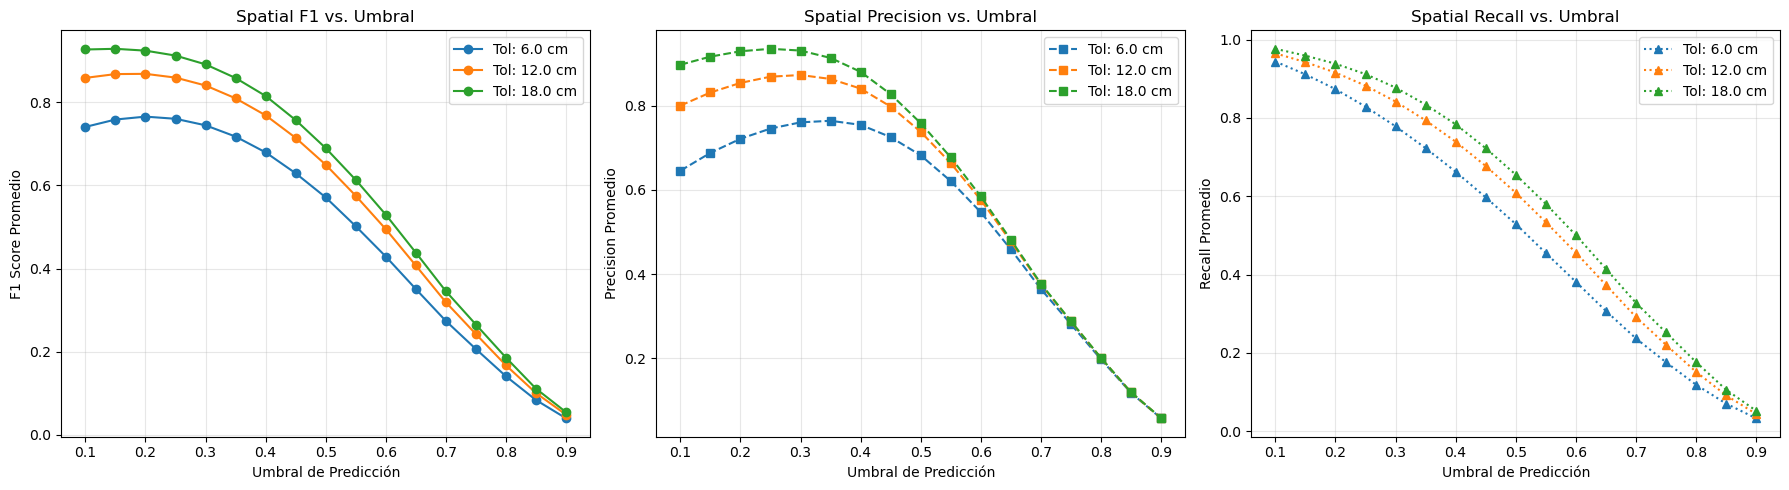


🏆 MEJOR CONFIGURACIÓN ENCONTRADA:
   F1 Espacial Máximo: 0.9284
   Umbral Óptimo:      0.15
   Radio de Tolerancia: 18.0 cm


In [48]:
# =============================================================================
# 5. PARTE B: MONTE CARLO (Barrido de Parámetros)
# =============================================================================
print("\n--- Ejecutando Monte Carlo (Barrido de Umbrales y Radios) ---")

# Parámetros del barrido
thresholds = np.linspace(0.1, 0.9, 17) # De 0.1 a 0.9 en pasos de 0.05
tolerances = [GRID_SIZE * 1, GRID_SIZE * 2, GRID_SIZE * 3] # [6.0, 12.0, 18.0]

# Almacenar resultados
history = {tol: {'f1': [], 'prec': [], 'rec': []} for tol in tolerances}

# Bucle principal (Iteramos sobre tolerancias y luego umbrales)
for tol in tolerances:
    print(f"Procesando radio de tolerancia: {tol} cm...")
    for th in tqdm(thresholds, leave=False):
        f1, p, r = evaluate_batch_spatial(y_test, y_pred_probs_all, th, tol, global_dist_matrix)
        history[tol]['f1'].append(f1)
        history[tol]['prec'].append(p)
        history[tol]['rec'].append(r)

# =============================================================================
# 6. VISUALIZACIÓN DE RESULTADOS
# =============================================================================
plt.figure(figsize=(18, 5))

# Gráfico 1: Spatial F1
plt.subplot(1, 3, 1)
for tol in tolerances:
    plt.plot(thresholds, history[tol]['f1'], marker='o', label=f'Tol: {tol} cm')
plt.title('Spatial F1 vs. Umbral')
plt.xlabel('Umbral de Predicción')
plt.ylabel('F1 Score Promedio')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: Spatial Precision
plt.subplot(1, 3, 2)
for tol in tolerances:
    plt.plot(thresholds, history[tol]['prec'], marker='s', linestyle='--', label=f'Tol: {tol} cm')
plt.title('Spatial Precision vs. Umbral')
plt.xlabel('Umbral de Predicción')
plt.ylabel('Precision Promedio')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 3: Spatial Recall
plt.subplot(1, 3, 3)
for tol in tolerances:
    plt.plot(thresholds, history[tol]['rec'], marker='^', linestyle=':', label=f'Tol: {tol} cm')
plt.title('Spatial Recall vs. Umbral')
plt.xlabel('Umbral de Predicción')
plt.ylabel('Recall Promedio')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Encontrar el mejor punto de operación
best_f1 = 0
best_cfg = (0, 0)

for tol in tolerances:
    f1s = history[tol]['f1']
    max_f1_idx = np.argmax(f1s)
    if f1s[max_f1_idx] > best_f1:
        best_f1 = f1s[max_f1_idx]
        best_cfg = (thresholds[max_f1_idx], tol)

print(f"\n🏆 MEJOR CONFIGURACIÓN ENCONTRADA:")
print(f"   F1 Espacial Máximo: {best_f1:.4f}")
print(f"   Umbral Óptimo:      {best_cfg[0]:.2f}")
print(f"   Radio de Tolerancia: {best_cfg[1]} cm")

Tenemos el problema de que nuestras metricas no penalizan la neblina de predicciones ni los objetos predichos fuera del radio de aceptacion. En consecuencia las metricas lucen mejor a menor valor de threshold. El siguiente paso es redefinir las metricas para penalizar los casos donde el threshold es bajo y muchas predicciones son hechas.

--- Cargando Datos y Modelo ---


Calculando matriz de distancias global...
Generando predicciones para todo el test set...
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  

--- Ejecutando Monte Carlo con Penalización de Densidad ---
Nota: max_preds_per_object = 4
Procesando Tolerancia: 6.0 cm...


  0%|          | 0/19 [00:00<?, ?it/s]

Procesando Tolerancia: 12.0 cm...


  0%|          | 0/19 [00:00<?, ?it/s]

Procesando Tolerancia: 18.0 cm...


  0%|          | 0/19 [00:00<?, ?it/s]

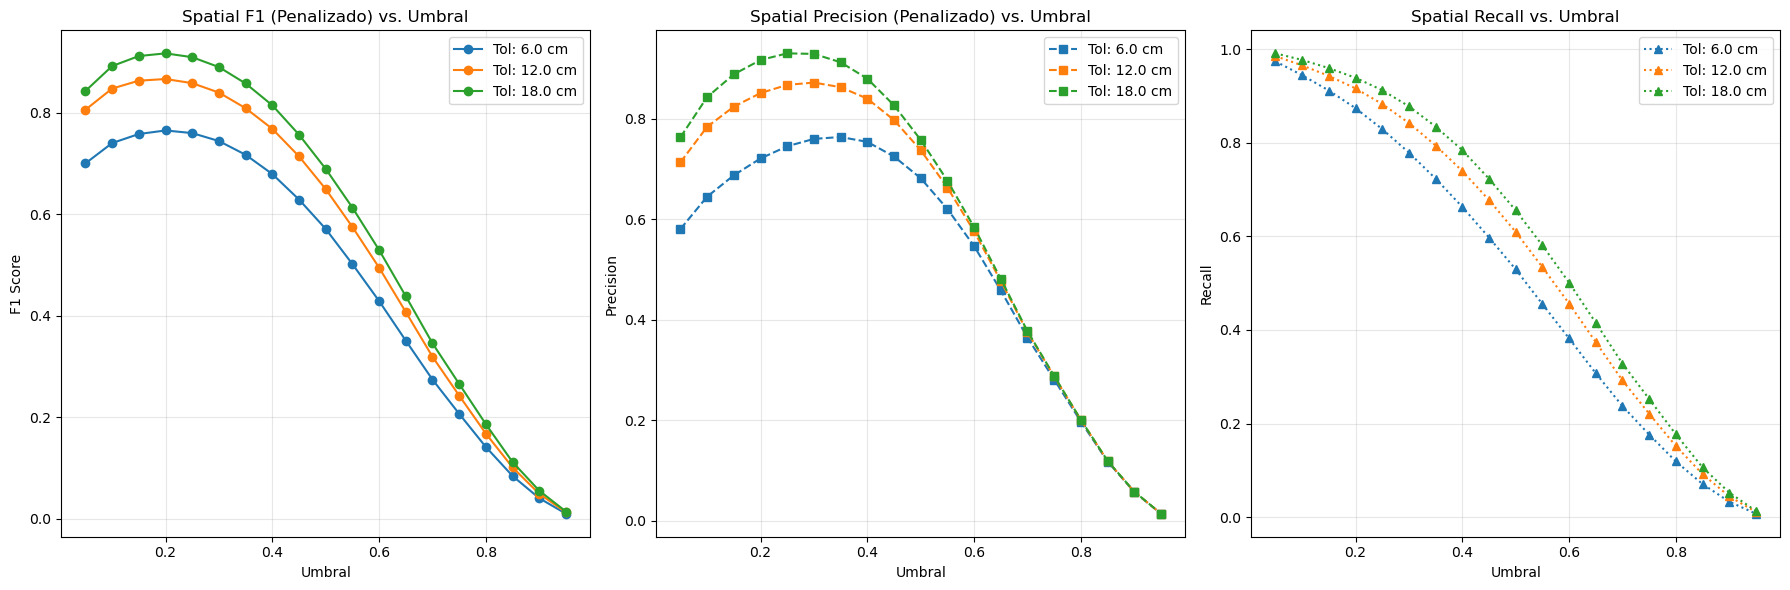


🏆 RESULTADO FINAL (ESTRICTO):
   F1 Máximo: 0.9174
   Umbral Óptimo: 0.20
   Tolerancia: 18.0 cm


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.spatial.distance import cdist
from keras.models import load_model
import tensorflow.keras.backend as K
from sklearn.model_selection import train_test_split
import pandas as pd

# =============================================================================
# 1. CONFIGURACIÓN Y CARGA
# =============================================================================

# Ajusta tus rutas si es necesario
MODEL_FILE = 'sonar_model_multiobjeto.h5'
X_FILE = 'datasets/features_150k_17_11_25.csv.npy'
Y_FILE = 'datasets/labels_150k_17_11_25.csv.npy'
MAP_FILE = 'mapa_de_cuadrantes.npy'
GRID_SIZE = 6.0 
ALLOWED_PREDS_PER_OBJECT = 4

# Métricas Keras (necesarias para cargar)
def recall_m(y_true, y_pred):
    return K.sum(K.round(K.clip(y_true * y_pred, 0, 1))) / (K.sum(K.round(K.clip(y_true, 0, 1))) + K.epsilon())
def precision_m(y_true, y_pred):
    return K.sum(K.round(K.clip(y_true * y_pred, 0, 1))) / (K.sum(K.round(K.clip(y_pred, 0, 1))) + K.epsilon())
def f1_m(y_true, y_pred):
    p = precision_m(y_true, y_pred); r = recall_m(y_true, y_pred)
    return 2 * ((p * r) / (p + r + K.epsilon()))

print("--- Cargando Datos y Modelo ---")
try:
    X_full = np.load(X_FILE)
    y_full = np.load(Y_FILE)
    mapa_centroides = np.load(MAP_FILE)
    custom_objects = {'f1_m': f1_m, 'precision_m': precision_m, 'recall_m': recall_m}
    model = load_model(MODEL_FILE, custom_objects=custom_objects)
except Exception as e:
    print(f"Error cargando archivos: {e}")

# Split y Normalización
X_train, X_test_raw, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_test = (X_test_raw - mean) / (std + 1e-7)
y_test = y_test.astype(int)

# =============================================================================
# 2. PRE-CÁLCULOS
# =============================================================================
print("Calculando matriz de distancias global...")
global_dist_matrix = cdist(mapa_centroides, mapa_centroides)

print("Generando predicciones para todo el test set...")
y_pred_probs_all = model.predict(X_test, verbose=1, batch_size=128)

# =============================================================================
# 3. NUEVA FUNCIÓN DE EVALUACIÓN (CON PENALIZACIÓN DE DENSIDAD)
# =============================================================================

def evaluate_spatial_density(y_true_batch, y_probs_batch, threshold, tolerance, dist_matrix, max_preds_per_object):
    """
    Calcula F1 Espacial penalizando el exceso de predicciones (neblina).
    max_preds_per_object: Cuántas predicciones cercanas puede 'validar' un solo objeto real.
                          Si es 1, la segunda predicción cercana cuenta como FP.
    """
    n_samples = y_true_batch.shape[0]
    f1_scores, prec_scores, rec_scores = [], [], []
    
    y_pred_bin = (y_probs_batch > threshold).astype(int)
    
    for i in range(n_samples):
        true_indices = np.where(y_true_batch[i] == 1)[0]
        pred_indices = np.where(y_pred_bin[i] == 1)[0]
        
        # --- Casos Borde ---
        if len(true_indices) == 0:
            if len(pred_indices) == 0:
                f1_scores.append(1.0); prec_scores.append(1.0); rec_scores.append(1.0)
            else:
                f1_scores.append(0.0); prec_scores.append(0.0); rec_scores.append(0.0) # FP puro
            continue
            
        if len(pred_indices) == 0:
            f1_scores.append(0.0); prec_scores.append(0.0); rec_scores.append(0.0) # FN puro
            continue

        # --- Submatriz de Distancias ---
        # Filas: Objetos Reales, Columnas: Predicciones
        dists = dist_matrix[np.ix_(true_indices, pred_indices)]
        
        # 1. RECALL (Igual que antes)
        # ¿Tiene el objeto real AL MENOS UNA predicción dentro del radio?
        has_match_true = np.any(dists <= tolerance, axis=1)
        spatial_tp_recall = np.sum(has_match_true)
        
        # 2. PRECISION (¡NUEVO: Con Límite de Densidad!)
        # Encontramos todos los pares (real, pred) que están cerca
        valid_pairs = np.argwhere(dists <= tolerance)
        
        if len(valid_pairs) > 0:
            # Obtenemos las distancias de estos pares válidos
            pair_distances = dists[valid_pairs[:, 0], valid_pairs[:, 1]]
            
            # Ordenamos los pares por distancia (de menor a mayor)
            # Esto prioriza las predicciones más cercanas al centro del objeto
            sorted_indices = np.argsort(pair_distances)
            valid_pairs = valid_pairs[sorted_indices]
            
            # Contadores para aplicar la restricción
            pred_is_tp = np.zeros(len(pred_indices), dtype=bool)
            true_obj_usage_count = np.zeros(len(true_indices), dtype=int)
            
            spatial_tp_precision = 0
            
            for r, c in valid_pairs:
                # r es índice del objeto real, c es índice de la predicción
                
                # Si esta predicción ya se asignó, saltar (no debería pasar con esta lógica, pero por seguridad)
                if pred_is_tp[c]: 
                    continue
                
                # Si el objeto real ya validó su cupo máximo de predicciones
                if true_obj_usage_count[r] < max_preds_per_object:
                    true_obj_usage_count[r] += 1
                    pred_is_tp[c] = True
                    spatial_tp_precision += 1
                # Si ya se llenó el cupo, esta predicción queda como False (FP)
            
        else:
            spatial_tp_precision = 0
            
        # Cálculos Finales
        rec = spatial_tp_recall / len(true_indices)
        prec = spatial_tp_precision / len(pred_indices) # Los FP (lejanos + neblina) bajan esto
        f1 = 2 * (prec * rec) / (prec + rec + 1e-7)
        
        f1_scores.append(f1)
        prec_scores.append(prec)
        rec_scores.append(rec)
        
    return np.mean(f1_scores), np.mean(prec_scores), np.mean(rec_scores)

# =============================================================================
# 4. MONTE CARLO MEJORADO
# =============================================================================

print("\n--- Ejecutando Monte Carlo con Penalización de Densidad ---")
print(f"Nota: max_preds_per_object = {ALLOWED_PREDS_PER_OBJECT}")

thresholds = np.linspace(0.05, 0.95, 19) # Más granular cerca de 0
tolerances = [GRID_SIZE * 1, GRID_SIZE * 2, GRID_SIZE * 3] # [6.0, 12.0, 18.0]

history = {tol: {'f1': [], 'prec': [], 'rec': []} for tol in tolerances}

for tol in tolerances:
    print(f"Procesando Tolerancia: {tol} cm...")
    for th in tqdm(thresholds, leave=False):
        # Usamos la nueva función con max_preds_per_object
        f1, p, r = evaluate_spatial_density(
            y_test, y_pred_probs_all, th, tol, global_dist_matrix, max_preds_per_object=ALLOWED_PREDS_PER_OBJECT
        )
        history[tol]['f1'].append(f1)
        history[tol]['prec'].append(p)
        history[tol]['rec'].append(r)

# =============================================================================
# 5. VISUALIZACIÓN
# =============================================================================
plt.figure(figsize=(18, 6))

# Gráfico 1: Spatial F1
plt.subplot(1, 3, 1)
for tol in tolerances:
    plt.plot(thresholds, history[tol]['f1'], 'o-', label=f'Tol: {tol} cm')
plt.title('Spatial F1 (Penalizado) vs. Umbral')
plt.xlabel('Umbral')
plt.ylabel('F1 Score')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: Spatial Precision
plt.subplot(1, 3, 2)
for tol in tolerances:
    plt.plot(thresholds, history[tol]['prec'], 's--', label=f'Tol: {tol} cm')
plt.title('Spatial Precision (Penalizado) vs. Umbral')
plt.xlabel('Umbral')
plt.ylabel('Precision')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 3: Spatial Recall
plt.subplot(1, 3, 3)
for tol in tolerances:
    plt.plot(thresholds, history[tol]['rec'], '^:', label=f'Tol: {tol} cm')
plt.title('Spatial Recall vs. Umbral')
plt.xlabel('Umbral')
plt.ylabel('Recall')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Encontrar el mejor punto
best_f1 = 0
best_cfg = (0, 0)

for tol in tolerances:
    f1s = history[tol]['f1']
    max_idx = np.argmax(f1s)
    if f1s[max_idx] > best_f1:
        best_f1 = f1s[max_idx]
        best_cfg = (thresholds[max_idx], tol)

print(f"\n🏆 RESULTADO FINAL (ESTRICTO):")
print(f"   F1 Máximo: {best_f1:.4f}")
print(f"   Umbral Óptimo: {best_cfg[0]:.2f}")
print(f"   Tolerancia: {best_cfg[1]} cm")